In [1]:
import torch
import numpy as np
import tifffile as tiff
import os
from torch.utils.data import DataLoader
from tqdm import tqdm
import sys
sys.path.append("../../../")
sys.path.append("/home/sheida.rahnamai/GIT/My_Plugin/epsSeg")
from boilerplate.dataloader import LabeledPatchDataset
import matplotlib.pyplot as plt
from torch.nn.functional import pairwise_distance

In [2]:

# Config
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
data_dir = "/group/jug/Sheida/pancreatic beta cells/download/"
model_path = "/group/jug/Sheida/HVAE/segmentation/06/model_unsupervised/segmentation_best_vae_7.net"


In [3]:

patch_size = (64, 64)
num_classes = [0, 1, 2, 3]
n_per_class = 100
batch_size = 400

# Load image + GT
test_image = tiff.imread(os.path.join(data_dir, "high_c4", "high_c4_source.tif"))
test_labels = tiff.imread(os.path.join(data_dir, "high_c4", "high_c4_gt.tif"))


In [4]:
test_image = np.expand_dims(test_image[500], axis=0)
test_labels = np.expand_dims(test_labels[500], axis=0)

In [5]:

# Dataset + Dataloader
dataset = LabeledPatchDataset(test_image, test_labels, patch_size=patch_size, num_per_class=n_per_class, classes=num_classes)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=4)


In [15]:

# Load model
model = torch.load(model_path)
model.eval()
model.mode_pred = True
device = model.device
data_mean = model.data_mean
data_std = model.data_std


In [16]:
# Storage
all_mus = []
all_coords = []
all_labels = []

with torch.no_grad():
    for patches, labels, coords in tqdm(dataloader):
        patches = patches.to(device)
        norm_patches = (patches - data_mean) / data_std

        output = model(norm_patches)
        mu_list = []
        for mu in output['mu']:
            bs, c, h, w = mu.shape
            mu_flat = mu.view(bs, -1)
            mu_list.append(mu_flat)

        mu_concat = torch.cat(mu_list, dim=1)  # shape: [B, F]
        all_mus.append(mu_concat.cpu())
        all_coords.append(torch.stack(coords, dim=1).float())  # [(z, y, x)...]
        all_labels.append(labels)

# Merge all batches
all_mus = torch.cat(all_mus, dim=0)           # [N, F]
all_coords = torch.cat(all_coords, dim=0)     # [N, 3]
all_labels = torch.cat(all_labels, dim=0)     # [N]

  0%|          | 0/1 [00:00<?, ?it/s]/home/sheida.rahnamai/miniconda3/envs/epsSeg/lib/python3.10/site-packages/torch/utils/checkpoint.py:31: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn("None of the inputs have requires_grad=True. Gradients will be None")
100%|██████████| 1/1 [00:00<00:00,  1.20it/s]


In [17]:
pred = []
with torch.no_grad():
    for patches, _, _ in tqdm(dataloader):
        patches = patches.to(device)
        norm_patches = (patches - data_mean) / data_std

        output = model(norm_patches)
        y_pred = output['pi'].argmax(dim=-1)
        pred.extend(y_pred.cpu().numpy())
        
pred_array = np.array(pred)
print(pred_array)

100%|██████████| 1/1 [00:00<00:00,  1.24it/s]

[0 2 0 2 0 1 0 2 0 0 2 2 0 2 1 1 0 1 1 1 1 0 3 0 2 0 2 2 2 0 1 0 1 1 1 1 0
 1 1 2 2 2 2 1 1 0 2 2 0 1 1 0 0 1 0 2 1 1 1 2 1 0 1 0 1 1 0 1 0 1 0 1 1 1
 1 0 0 0 2 0 2 1 0 2 2 0 1 1 3 2 2 1 1 1 1 0 1 2 1 1 1 0 2 0 0 0 0 1 0 1 1
 0 3 2 2 0 1 1 1 0 2 2 2 1 1 0 0 1 2 0 1 2 1 1 0 0 0 1 0 3 0 0 0 2 0 0 1 1
 1 1 3 1 2 1 0 2 0 0 0 0 1 2 2 0 2 2 0 0 2 2 1 0 0 0 1 0 1 0 3 1 0 3 0 0 0
 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 2 0 0 0 0 1 2 1 2 1 1 0 1 2 2 2 1 1 2 2
 3 2 0 2 1 3 1 1 0 1 1 2 0 2 0 0 2 1 0 0 1 2 1 2 0 1 3 1 2 2 1 0 2 3 1 2 0
 1 1 0 1 1 2 1 1 2 0 0 2 2 1 2 2 1 1 1 1 1 1 0 1 1 0 0 1 2 1 2 1 0 1 1 1 1
 1 2 1 1 2 2 2 1 1 0 0 2 1 2 1 0 1 1 0 3 0 3 2 2 0 2 2 0 0 1 1 0 1 0 0 2 3
 0 0 0 2 0 2 2 1 0 1 2 2 0 3 0 3 3 0 2 0 2 2 2 3 3 2 1 3 0 2 3 2 2 2 0 2 0
 0 2 0 3 1 1 1 0 2 0 0 1 0 0 1 0 0 2 2 1 2 2 2 0 2 0 1 2 2 2]


In [18]:
from itertools import combinations

pairs = list(combinations(range(400), 2))  # 79800 for N=400

In [19]:

# Compute pairwise distances
print("Computing pairwise distances...")

latent_dist = torch.cdist(all_mus, all_mus, p=2)      # [N, N]
pixel_dist = torch.cdist(all_coords, all_coords, p=2) # [N, N]
label_eq = (all_labels.unsqueeze(1) == all_labels.unsqueeze(0))  # [N, N]

# Mask
intra_mask = torch.triu(label_eq, diagonal=1)
inter_mask = torch.triu(~label_eq, diagonal=1)

# Extract distances
latent_intra = latent_dist[intra_mask]
latent_inter = latent_dist[inter_mask]
pixel_intra = pixel_dist[intra_mask]
pixel_inter = pixel_dist[inter_mask]


Computing pairwise distances...


In [20]:
import pandas as pd

data = []

for i, j in pairs:
    pix_d = pixel_dist[i, j].item()
    lat_d = latent_dist[i, j].item()
    same = bool(labels[i] == labels[j])
    data.append((pix_d, lat_d, same))

df = pd.DataFrame(data, columns=['pixel_dist', 'latent_dist', 'same_class'])


/tmp/ipykernel_2241/2205792636.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df.same_class]['latent_dist'], label="Intra-class", shade=True)
/tmp/ipykernel_2241/2205792636.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[~df.same_class]['latent_dist'], label="Inter-class", shade=True)


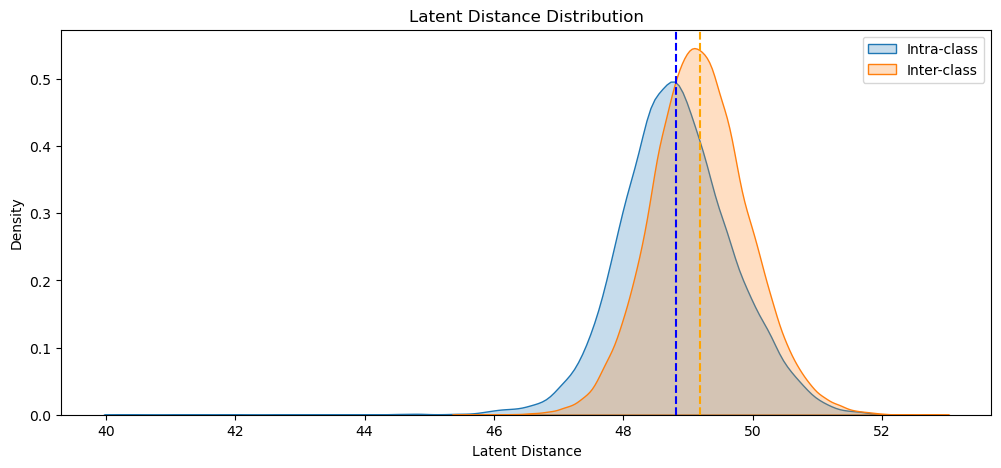

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Latent
sns.kdeplot(df[df.same_class]['latent_dist'], label="Intra-class", shade=True)
sns.kdeplot(df[~df.same_class]['latent_dist'], label="Inter-class", shade=True)
plt.axvline(df[df.same_class]['latent_dist'].mean(), color='blue', linestyle='--')
plt.axvline(df[~df.same_class]['latent_dist'].mean(), color='orange', linestyle='--')
plt.title("Latent Distance Distribution")
plt.xlabel("Latent Distance")
plt.legend()
plt.show()


/tmp/ipykernel_2241/1204797502.py:31: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df.same_class]['latent_dist'], label=f"{target_class}-{target_class} (intra)", shade=True)
/tmp/ipykernel_2241/1204797502.py:32: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[~df.same_class]['latent_dist'], label=f"{target_class}-others (inter)", shade=True)


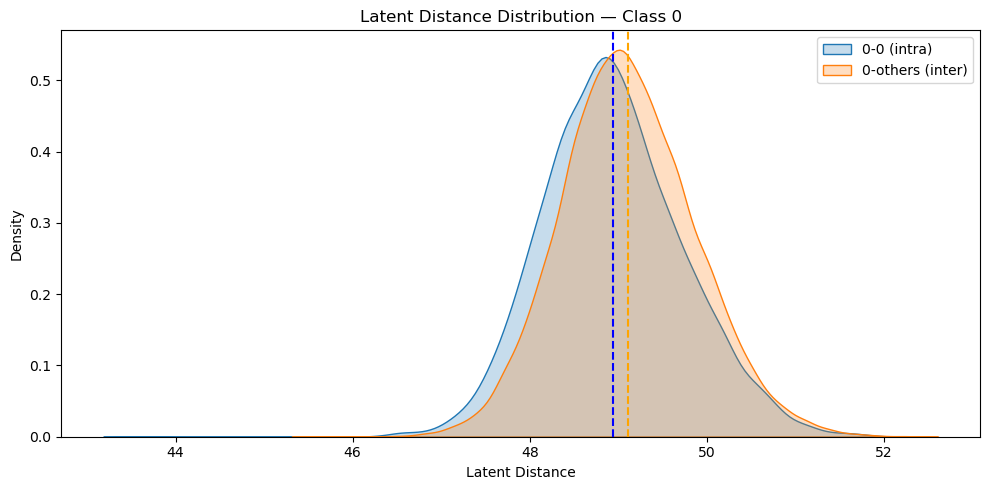

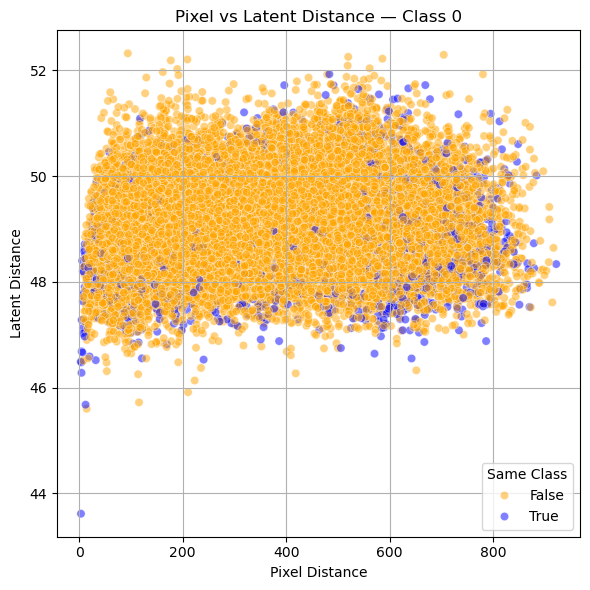

/tmp/ipykernel_2241/1204797502.py:31: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df.same_class]['latent_dist'], label=f"{target_class}-{target_class} (intra)", shade=True)
/tmp/ipykernel_2241/1204797502.py:32: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[~df.same_class]['latent_dist'], label=f"{target_class}-others (inter)", shade=True)


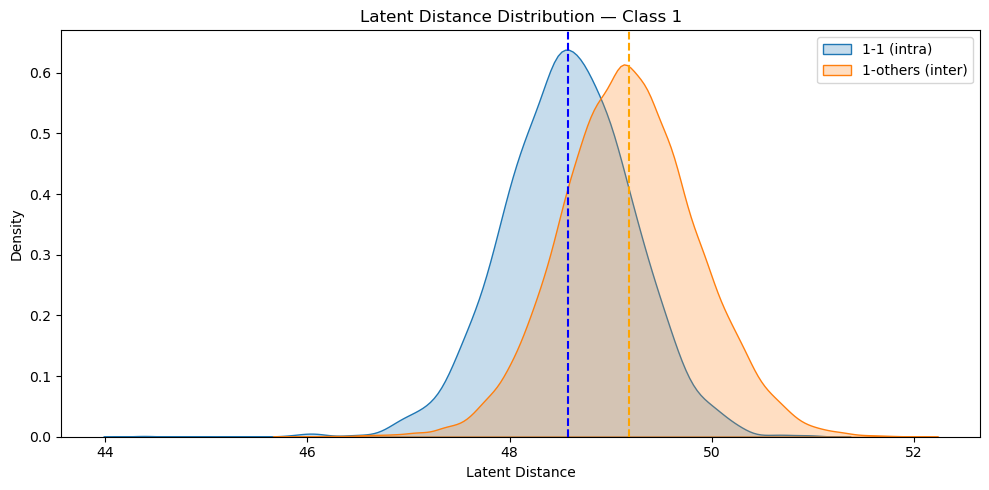

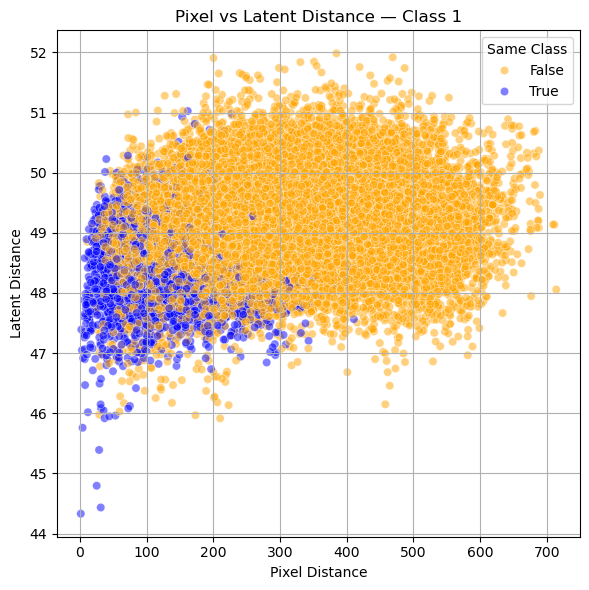

/tmp/ipykernel_2241/1204797502.py:31: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df.same_class]['latent_dist'], label=f"{target_class}-{target_class} (intra)", shade=True)
/tmp/ipykernel_2241/1204797502.py:32: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[~df.same_class]['latent_dist'], label=f"{target_class}-others (inter)", shade=True)


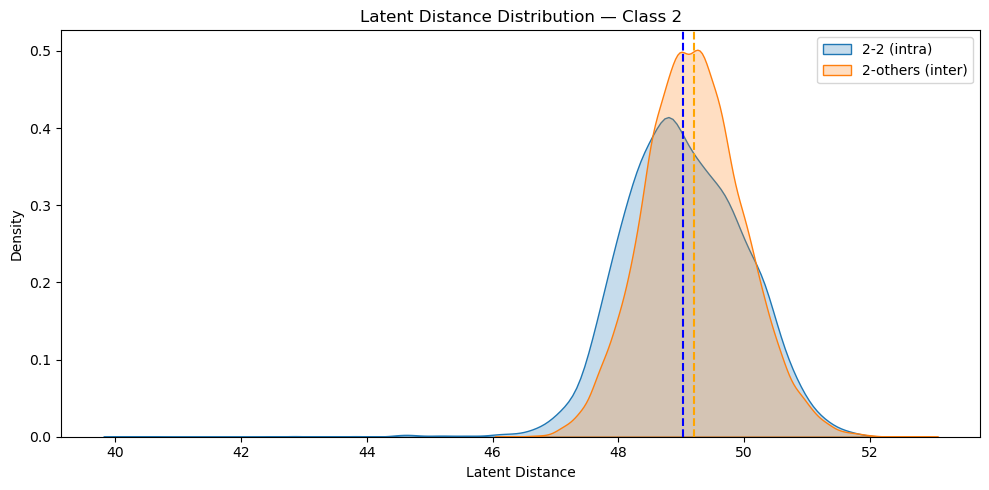

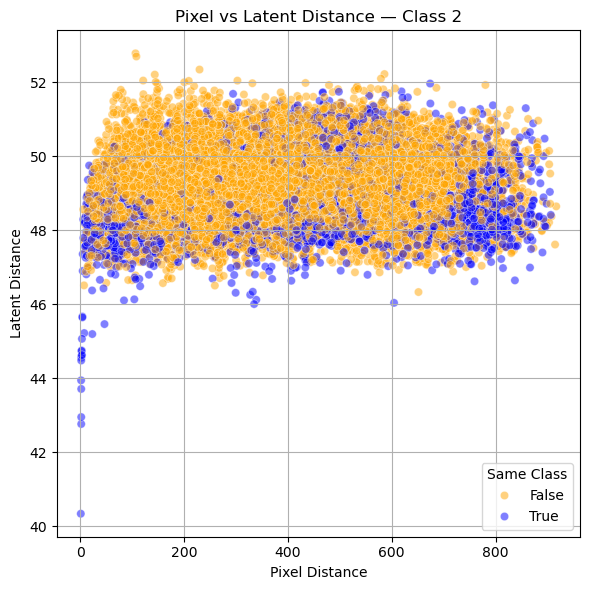

/tmp/ipykernel_2241/1204797502.py:31: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df.same_class]['latent_dist'], label=f"{target_class}-{target_class} (intra)", shade=True)
/tmp/ipykernel_2241/1204797502.py:32: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[~df.same_class]['latent_dist'], label=f"{target_class}-others (inter)", shade=True)


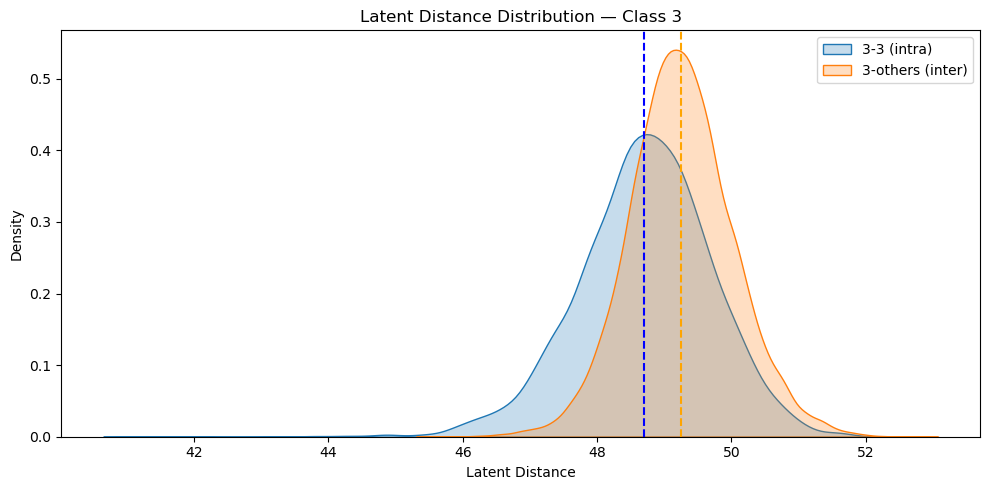

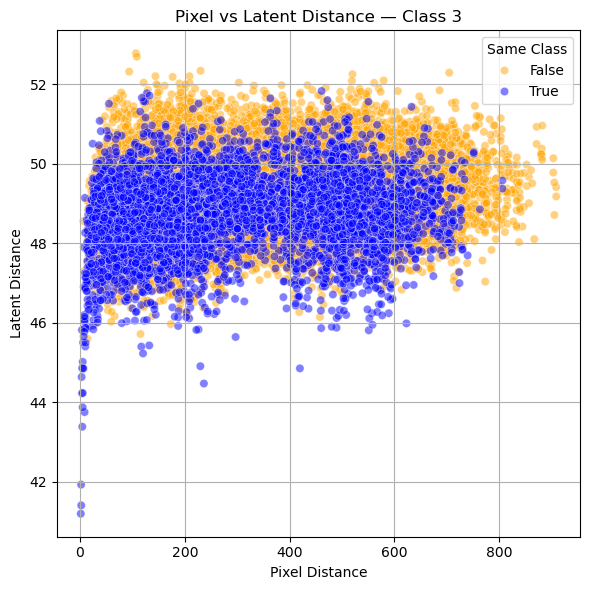

In [22]:
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt
pairs = list(combinations(range(len(labels)), 2))
for target_class in range(4):
    data = []

    for i, j in pairs:
        label_i = labels[i].item() if isinstance(labels[i], torch.Tensor) else labels[i]
        label_j = labels[j].item() if isinstance(labels[j], torch.Tensor) else labels[j]

        pix_d = pixel_dist[i, j].item()
        lat_d = latent_dist[i, j].item()

        # Define class-based logic
        if label_i == target_class and label_j == target_class:
            same = True  # positive pair
        elif label_i == target_class or label_j == target_class:
            same = False  # inter-class (one is the class of interest)
        else:
            continue  # skip all other (non-target) pairs

        data.append((pix_d, lat_d, same))

    # Create DataFrame
    import pandas as pd
    df = pd.DataFrame(data, columns=['pixel_dist', 'latent_dist', 'same_class'])
    

    plt.figure(figsize=(10, 5))
    sns.kdeplot(df[df.same_class]['latent_dist'], label=f"{target_class}-{target_class} (intra)", shade=True)
    sns.kdeplot(df[~df.same_class]['latent_dist'], label=f"{target_class}-others (inter)", shade=True)

    plt.axvline(df[df.same_class]['latent_dist'].mean(), color='blue', linestyle='--')
    plt.axvline(df[~df.same_class]['latent_dist'].mean(), color='orange', linestyle='--')

    plt.title(f"Latent Distance Distribution — Class {target_class}")
    plt.xlabel("Latent Distance")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 6))
    sns.scatterplot(
        data=df, 
        x='pixel_dist', 
        y='latent_dist', 
        hue='same_class',
        palette={True: 'blue', False: 'orange'}, 
        alpha=0.5
    )
    plt.title(f"Pixel vs Latent Distance — Class {target_class}")
    plt.xlabel("Pixel Distance")
    plt.ylabel("Latent Distance")
    plt.legend(title="Same Class")
    plt.grid(True)
    plt.tight_layout()
    plt.show()



In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=100, svd_solver='full', random_state=42)
mus_reduced = pca.fit_transform(all_mus.cpu().numpy())  # shape: [N, 400]


In [ ]:

# Compute pairwise distances
print("Computing pairwise distances...")
mus_reduced = torch.tensor(mus_reduced)  # Convert to tensor and move to device
latent_dist_pca = torch.cdist(mus_reduced, mus_reduced, p=2)      # [N, N]
pixel_dist = torch.cdist(all_coords, all_coords, p=2) # [N, N]
label_eq = (all_labels.unsqueeze(1) == all_labels.unsqueeze(0))  # [N, N]

# Mask
intra_mask = torch.triu(label_eq, diagonal=1)
inter_mask = torch.triu(~label_eq, diagonal=1)

# Extract distances
latent_intra = latent_dist_pca[intra_mask]
latent_inter = latent_dist_pca[inter_mask]
pixel_intra = pixel_dist[intra_mask]
pixel_inter = pixel_dist[inter_mask]


In [ ]:
import pandas as pd

data = []

for i, j in pairs:
    pix_d = pixel_dist[i, j].item()
    lat_d = latent_dist_pca[i, j].item()
    same = bool(labels[i] == labels[j])
    data.append((pix_d, lat_d, same))

df = pd.DataFrame(data, columns=['pixel_dist', 'latent_dist', 'same_class'])

In [ ]:
latent_dist_pca

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Latent
sns.kdeplot(df[df.same_class]['latent_dist'], label="Intra-class", shade=True)
sns.kdeplot(df[~df.same_class]['latent_dist'], label="Inter-class", shade=True)
plt.axvline(df[df.same_class]['latent_dist'].mean(), color='blue', linestyle='--')
plt.axvline(df[~df.same_class]['latent_dist'].mean(), color='orange', linestyle='--')
plt.title("Latent Distance Distribution")
plt.xlabel("Latent Distance")
plt.legend()
plt.show()

from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt
pairs = list(combinations(range(len(labels)), 2))
for target_class in range(4):
    data = []

    for i, j in pairs:
        label_i = labels[i].item() if isinstance(labels[i], torch.Tensor) else labels[i]
        label_j = labels[j].item() if isinstance(labels[j], torch.Tensor) else labels[j]

        pix_d = pixel_dist[i, j].item()
        lat_d = latent_dist_pca[i, j].item()

        # Define class-based logic
        if label_i == target_class and label_j == target_class:
            same = True  # positive pair
        elif label_i == target_class or label_j == target_class:
            same = False  # inter-class (one is the class of interest)
        else:
            continue  # skip all other (non-target) pairs

        data.append((pix_d, lat_d, same))

    # Create DataFrame
    import pandas as pd
    df = pd.DataFrame(data, columns=['pixel_dist', 'latent_dist', 'same_class'])
    

    plt.figure(figsize=(10, 5))
    sns.kdeplot(df[df.same_class]['latent_dist'], label=f"{target_class}-{target_class} (intra)", shade=True)
    sns.kdeplot(df[~df.same_class]['latent_dist'], label=f"{target_class}-others (inter)", shade=True)

    plt.axvline(df[df.same_class]['latent_dist'].mean(), color='blue', linestyle='--')
    plt.axvline(df[~df.same_class]['latent_dist'].mean(), color='orange', linestyle='--')

    plt.title(f"Latent Distance Distribution — Class {target_class}")
    plt.xlabel("Latent Distance")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(10, 5))
    sns.kdeplot(df[df.same_class]['pixel_dist'], label=f"{target_class}-{target_class} (intra)", shade=True)
    sns.kdeplot(df[~df.same_class]['pixel_dist'], label=f"{target_class}-others (inter)", shade=True)

    plt.axvline(df[df.same_class]['pixel_dist'].mean(), color='blue', linestyle='--')
    plt.axvline(df[~df.same_class]['pixel_dist'].mean(), color='orange', linestyle='--')

    plt.title(f"Pixel Distance Distribution — Class {target_class}")
    plt.xlabel("Pixel Distance")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    sns.kdeplot(
    data=df[df.same_class], x='pixel_dist', y='latent_dist', fill=True, cmap='Blues', label='Intra-class'
    )
    sns.kdeplot(
        data=df[~df.same_class], x='pixel_dist', y='latent_dist', fill=True, cmap='Oranges', label='Inter-class'
    )
    plt.title(f"Joint Density — Class {target_class}")
    plt.xlabel("Pixel Distance")
    plt.ylabel("Latent Distance")
    plt.legend()
    plt.show()





In [ ]:
from scipy.stats import pearsonr

orig_flat = latent_dist.numpy().flatten()
pca_flat  = latent_dist_pca.numpy().flatten()

corr, _ = pearsonr(orig_flat, pca_flat)
print(f"Pearson correlation of distances: {corr:.4f}")


In [ ]:
N = all_labels.shape[0]
triu_indices = torch.triu_indices(N, N, offset=1)

i = triu_indices[0]
j = triu_indices[1]

# Get values
x_vals = pixel_dist[i, j]   # [M]
y_vals = latent_dist[i, j]  # [M]

# Get label pairs
label_i = all_labels[i]
label_j = all_labels[j]

# Create label pair string (sorted for symmetry)
pair_labels = [f"{min(a.item(), b.item())}-{max(a.item(), b.item())}" for a, b in zip(label_i, label_j)]


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Put into a DataFrame for ease of plotting
df = pd.DataFrame({
    'pixel_dist': x_vals.numpy(),
    'latent_dist': y_vals.numpy(),
    'pair': pair_labels
})

# Set unique color palette
unique_pairs = sorted(set(pair_labels))
palette = sns.color_palette("tab10", n_colors=len(unique_pairs))
pair_color_map = {pair: palette[i] for i, pair in enumerate(unique_pairs)}


In [ ]:
plt.figure(figsize=(10, 8))
for pair in unique_pairs:
    subset = df[df['pair'] == pair]
    plt.scatter(subset['pixel_dist'], subset['latent_dist'], s=10, alpha=0.6, label=pair, color=pair_color_map[pair])

plt.xlabel("Pixel-space Distance")
plt.ylabel("Latent-space Distance")
plt.title("Latent vs Pixel Distance by Class Pair")
plt.legend(title="Class Pair", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
N = all_labels.shape[0]
triu_indices = torch.triu_indices(N, N, offset=1)

i = triu_indices[0]
j = triu_indices[1]

# Get values
x_vals = pixel_dist[i, j].cpu().numpy()
y_vals = latent_dist[i, j].cpu().numpy()

# Label pairs (not sorted — to distinguish 0-1 from 1-0)
label_i = all_labels[i].cpu().numpy()
label_j = all_labels[j].cpu().numpy()

In [ ]:
from collections import defaultdict

pair_data = defaultdict(lambda: {'x': [], 'y': []})

for x, y, a, b in zip(x_vals, y_vals, label_i, label_j):
    pair_data[(a, b)]['x'].append(x)
    pair_data[(a, b)]['y'].append(y)


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 4, figsize=(16, 16), sharex=True, sharey=True)

for a in range(4):
    for b in range(4):
        ax = axes[a, b]
        data = pair_data.get((a, b), None)
        
        if data and len(data['x']) > 0:
            ax.scatter(data['x'], data['y'], s=8, alpha=0.6)
        
        ax.set_title(f"Class {a} - {b}")
        if a == 3:
            ax.set_xlabel("Pixel Distance")
        if b == 0:
            ax.set_ylabel("Latent Distance")

plt.suptitle("Latent vs Pixel Distance for Each Class Pair", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


In [ ]:
triu = torch.triu_indices(N, N, offset=1)
i = triu[0]
j = triu[1]

label_i = all_labels[i].cpu().numpy()
label_j = all_labels[j].cpu().numpy()
pix_vals = pixel_dist[i, j].cpu().numpy()
lat_vals = latent_dist[i, j].cpu().numpy()

In [ ]:
from collections import defaultdict
import scipy.stats as stats

intra_class_corrs = {}
inter_class_corrs = {}

classes = sorted(set(all_labels.tolist()))

for a in classes:
    # Intra-class (a == b)
    mask = (label_i == a) & (label_j == a)
    if mask.sum() > 0:
        pix_a = pix_vals[mask]
        lat_a = lat_vals[mask]
        intra_class_corrs[a] = {
            "pearson": stats.pearsonr(pix_a, lat_a),
            "spearman": stats.spearmanr(pix_a, lat_a)
        }

    # Inter-class (a != b)
    for b in classes:
        if a >= b:
            continue  # avoid duplicates

        mask = ((label_i == a) & (label_j == b)) | ((label_i == b) & (label_j == a))
        if mask.sum() > 0:
            pix_ab = pix_vals[mask]
            lat_ab = lat_vals[mask]
            inter_class_corrs[(a, b)] = {
                "pearson": stats.pearsonr(pix_ab, lat_ab),
                "spearman": stats.spearmanr(pix_ab, lat_ab)
            }

In [ ]:
print("\n🔷 Intra-class Correlation:")
for c, corrs in intra_class_corrs.items():
    print(f"Class {c}-{c} | Pearson: {corrs['pearson'][0]:.3f}, Spearman: {corrs['spearman'][0]:.3f}")

print("\n🔶 Inter-class Correlation:")
for (a, b), corrs in inter_class_corrs.items():
    print(f"Class {a}-{b} | Pearson: {corrs['pearson'][0]:.3f}, Spearman: {corrs['spearman'][0]:.3f}")

In [ ]:

# Plot
plt.figure(figsize=(10, 5))
plt.hist(latent_intra.numpy(), bins=100, alpha=0.5, label="Latent Intra")
plt.hist(latent_inter.numpy(), bins=100, alpha=0.5, label="Latent Inter")
plt.xlabel("Latent μ Distance")
plt.ylabel("Frequency")
plt.legend()
plt.title("Latent Space Distance Distribution")
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(pixel_intra.numpy(), bins=100, alpha=0.5, label="Pixel Intra")
plt.hist(pixel_inter.numpy(), bins=100, alpha=0.5, label="Pixel Inter")
plt.xlabel("Pixel (center) Distance")
plt.ylabel("Frequency")
plt.legend()
plt.title("Center Pixel Distance Distribution")
plt.show()

In [ ]:
import pandas as pd
df = pd.read_csv("points.csv")

import matplotlib.pyplot as plt
plt.scatter(df["pixel_val"], df["latent_val"], s=3)
plt.xlabel("pixel_vals")
plt.ylabel("latent_vals")
plt.title("Saved Points")
plt.show()

In [ ]:
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Step 1: Load the full set of points
df = pd.read_csv("points_t.csv")

# Step 2: Load the index matrix (4x4)
q_matrix = torch.load("q_indices_t.pt")  # shape: (4, 4)

# Step 3: Convert DataFrame columns to tensors for indexing
pixel_vals = torch.tensor(df["pixel_val"].values)
latent_vals = torch.tensor(df["latent_val"].values)

# Step 4: Extract x and y coordinates of the 16 selected points
highlight_x = []
highlight_y = []
for row in q_matrix:
    for idx in row:
        highlight_x.append(pixel_vals[idx].item())
        highlight_y.append(latent_vals[idx].item())

# Step 5: Plot
plt.figure(figsize=(8, 6))
plt.scatter(df["pixel_val"], df["latent_val"], s=3, alpha=0.5, label="All Points")
plt.scatter(highlight_x, highlight_y, color='red', s=50, marker='x', label="Selected Corner Points")
plt.xlabel("pixel_vals")
plt.ylabel("latent_vals")
plt.title("Selected Corner Points on Scatter Plot")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
def get_percentile_quadrants(pixel_vals, latent_vals, k=4):
    
    x_10 = pixel_vals.kthvalue(int(0.10 * len(pixel_vals)))[0]
    x_25 = pixel_vals.kthvalue(int(0.25 * len(pixel_vals)))[0]
    x_75 = pixel_vals.kthvalue(int(0.75 * len(pixel_vals)))[0]
    x_90 = pixel_vals.kthvalue(int(0.90 * len(pixel_vals)))[0]

    y_10 = latent_vals.kthvalue(int(0.05 * len(latent_vals)))[0]
    y_25 = latent_vals.kthvalue(int(0.15 * len(latent_vals)))[0]
    y_75 = latent_vals.kthvalue(int(0.85 * len(latent_vals)))[0]
    y_90 = latent_vals.kthvalue(int(0.95 * len(latent_vals)))[0]

    quadrants = {}

    # Define inter-percentile masks
    masks = {
        "top_left":     (pixel_vals >= x_10) & (pixel_vals <= x_25) & (latent_vals >= y_75) & (latent_vals <= y_90),
        "top_right":    (pixel_vals >= x_75) & (pixel_vals <= x_90) & (latent_vals >= y_75) & (latent_vals <= y_90),
        "bottom_left":  (pixel_vals >= x_10) & (pixel_vals <= x_25) & (latent_vals >= y_10) & (latent_vals <= y_25),
        "bottom_right": (pixel_vals >= x_75) & (pixel_vals <= x_90) & (latent_vals >= y_10) & (latent_vals <= y_25),
    }

    for name, mask in masks.items():
        x = pixel_vals[mask]
        y = latent_vals[mask]
        indices = torch.arange(len(pixel_vals), device=pixel_vals.device)[mask]

        if x.numel() == 0:
            print(f"Warning: No points found in {name} quadrant.")
            quadrants[name] = []
            continue

        # Sort logic: for top -> highest y, for bottom -> lowest y
        if name.startswith("top"):
            sort_key = torch.stack([-y, x], dim=1)
        else:
            sort_key = torch.stack([y, x], dim=1)

        x_sort = torch.argsort(sort_key[:, 1], stable=True)
        yx_sort = torch.argsort(sort_key[x_sort, 0], stable=True)
        selected = indices[x_sort[yx_sort]][:k]
        quadrants[name] = selected

    return quadrants

q = get_percentile_quadrants(pixel_vals, latent_vals, k=4)

# Save to a text/CSV file
pixel_vals_cpu = pixel_vals.detach().cpu()
latent_vals_cpu = latent_vals.detach().cpu()

with open("points_t.csv", "w") as f:
    f.write("pixel_val,latent_val\n")
    for x, y in zip(pixel_vals_cpu, latent_vals_cpu):
        f.write(f"{x.item()},{y.item()}\n")
        
quadrant_order = ['top_left', 'top_right', 'bottom_left', 'bottom_right']
matrix = torch.stack([q[key] for key in quadrant_order])  # shape: (4, 4)
# Save to text
torch.save(matrix, "q_indices_t.pt")

# Or save as human-readable text
with open("q_indices_t.txt", "w") as f:
    for row in matrix:
        f.write(" ".join(str(i.item()) for i in row) + "\n")


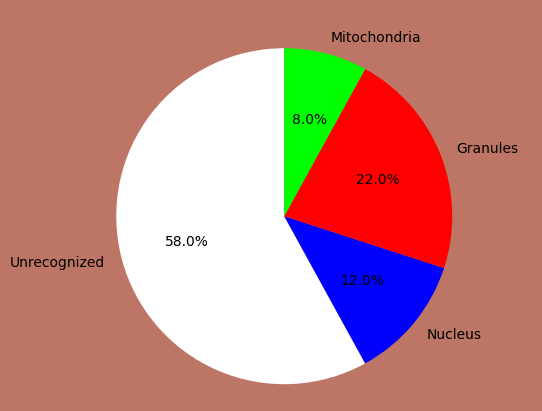

In [4]:
import matplotlib.pyplot as plt

# Data
labels = ['Unrecognized', 'Nucleus', 'Granules', 'Mitochondria']
sizes = [58, 12, 22, 8]

# Custom colors (taken from your image)
colors = ['#ffffff', '#0000ff', '#ff0000', '#00ff00']

# Plot
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
ax.set_facecolor('#bd7565')  # background color of plot
fig.patch.set_facecolor('#bd7565')  # background color of figure
ax.axis('equal')

plt.title(" ")
plt.show()


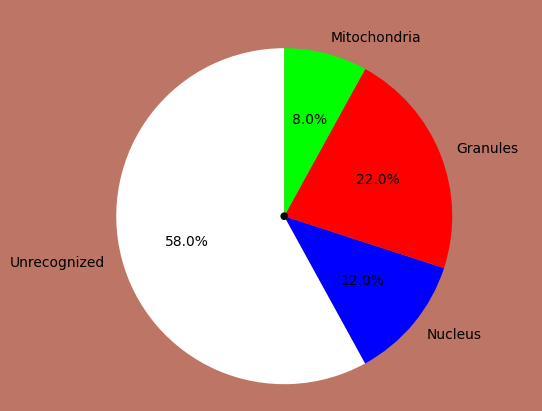

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Data
labels = ['Unrecognized', 'Nucleus', 'Granules', 'Mitochondria']
sizes = [58, 12, 22, 8]

# Custom colors
colors = ['#ffffff', '#0000ff', '#ff0000', '#00ff00']

# Plot
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)

# Background
ax.set_facecolor('#bd7565')
fig.patch.set_facecolor('#bd7565')
ax.axis('equal')

# Compute radius for 0.035% subset
subset_fraction = 0.00035  # 0.035%
R = 1.0  # pie radius
r = np.sqrt(subset_fraction) * R  # proportional radius

# Draw small circle
inner_circle = plt.Circle((0, 0), r, color='black', label="0.035% subset")
ax.add_artist(inner_circle)

# Optional: add text inside the circle
# ax.text(0, 0, "0.035%", color="white", ha="center", va="center", fontsize=6)

plt.title(" ")
plt.show()


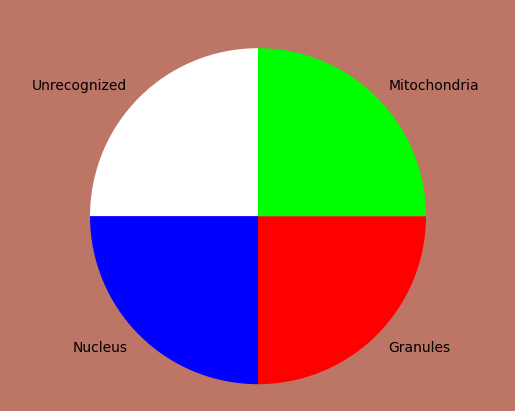

In [9]:
import matplotlib.pyplot as plt

# Data
labels = ['Unrecognized', 'Nucleus', 'Granules', 'Mitochondria']
sizes = [25, 25, 25, 25]

# Custom colors (taken from your image)
colors = ['#ffffff', '#0000ff', '#ff0000', '#00ff00']

# Plot
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels,  startangle=90, colors=colors)
ax.set_facecolor('#bd7565')  # background color of plot
fig.patch.set_facecolor('#bd7565')  # background color of figure
ax.axis('equal')

plt.title(" ")
plt.show()